# Correlation lag-tau experiments

This notebook calculates the tau-generalized, lagged Pearson-correlation
assignments for the canonical temperature/TSI dyads. It loads the required real
and surrogate series directly from the shared master time-series stores.

It's the calculation behind Text S3 and Fig. S8: a deliberately simple linear
alternative to CCM, pushed through as close to the same pipeline as possible (same
dyads, same τ-based resampling, same ±20-timestep lag scan, same phase-randomized
surrogate significance test) so the two methods are genuinely comparable. The
question comes straight from Discussion: *"If TSI were a dominant or direct driver
of climate variability, a simple linear relationship would be expected and
recoverable by simple correlation."* Finding that simple correlation is mostly
insignificant where CCM finds discernible influence (Fig. S10 = CCM skill minus this
correlation) is evidence that the TSI–temperature relationship is real, just better
described in state space than as a fixed linear coupling.


## Workflow

1. Run the single-dyad walkthrough: calculate one dyad, then inspect its lag profiles.
2. When ready, run the complete canonical batch in the later section.
3. Optionally update the compact ResultsGrid input from the batch result.

The walkthrough keeps the notebook useful as an explorable calculation. The batch section only returns compact assignment summaries.


## Imports and experiment controls


In [46]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

from cedarkit.core.data_var import VarObject
from cedarkit.utils.io.timeseries_utils import remove_extra_index


In [47]:
# Single-dyad walkthrough controls
tau_values = list(range(1, 8))
lag_ts_limit = 20
peak_window_halfwidth = 3
min_lag = -1  # select the maximum |r| among lags >= -1

single_pair_label = 'Alley-Vieira'
single_row_category = 'original'


## Locate source time series


In [48]:
# Correlation uses the shared master series directly; it does not need
# dyad project directories or proj_config.yaml files.
stem = Path(*(p := Path.cwd().resolve()).parts[: p.parts.index("notebooks")])
DATA_ROOT = stem / "hol_temp_tsi_ccm"
MASTER_DATA_DIR = DATA_ROOT / "master_data"
MASTER_SURROGATES_DIR = DATA_ROOT / "master_surrogates"
HT_ROOT = DATA_ROOT

for required_dir in (MASTER_DATA_DIR, MASTER_SURROGATES_DIR):
    if not required_dir.is_dir():
        raise FileNotFoundError(f"Missing shared time-series directory: {required_dir}")


def load_master_var_object(var_id: str) -> VarObject:
    # Load one configured real series from the shared master time-series stores.
    var_obj = VarObject(None, var_id, DATA_ROOT)
    var_obj.using_master_config = True
    var_obj.get_real()
    if getattr(var_obj, "ts", None) is None or var_obj.ts.empty:
        raise ValueError(f"{var_id} did not load a usable real time series.")
    return var_obj


## Correlation calculation helpers


In [49]:
def load_surrogate_table(var_obj: VarObject) -> pd.DataFrame:
    surr_path = var_obj.surr_data_dir_path / f'{var_obj.surr_ts_csv}.csv'
    if not surr_path.exists():
        raise FileNotFoundError(f'Missing surrogate table for {var_obj.var_id}: {surr_path}')
    surr_df = pd.read_csv(surr_path)
    surr_df = remove_extra_index(surr_df)
    surr_df, _ = var_obj.standardize_time_var(var_obj.surr_ts_time, surr_df, var_obj.surr_prefix)
    if 'time' not in surr_df.columns:
        raise ValueError(f'Failed to standardize surrogate time column for {var_obj.var_id}: {surr_path}')
    return surr_df


In [50]:
def extract_surr_num(col_name: str):
    m = re.search(r'_(\d+)$', str(col_name))
    return int(m.group(1)) if m else np.nan


def lag_then_sample_corr(pair_df: pd.DataFrame, x_name: str, y_name: str, lag_ts: int, tau: int, phase: int):
    tmp = pair_df[[x_name, y_name]].copy()
    tmp[y_name] = tmp[y_name].shift(lag_ts)
    tmp = tmp.dropna().reset_index(drop=True)
    if len(tmp) < 3:
        return np.nan, len(tmp)
    tmp = tmp.iloc[phase::tau].reset_index(drop=True)
    if len(tmp) < 3:
        return np.nan, len(tmp)
    r = tmp[x_name].corr(tmp[y_name], method='pearson')
    return (np.abs(r) if pd.notna(r) else np.nan), len(tmp)


def compute_corr_profiles(
    pair_real, surr_x, surr_y,
    x_col, y_col, col_var_id, target_var_id,
    tau_values, lag_ts_limit,
    min_lag=-1, peak_window_halfwidth=3,
):
    lag_ts_values = list(range(-lag_ts_limit, lag_ts_limit + 1))

    y_surr_cols = [c for c in surr_y.columns if c != 'time'][1:]
    x_surr_cols = [c for c in surr_x.columns if c != 'time'][1:]

    y_surr_pairs = {
        s_col: pair_real[['time', x_col]].merge(
            surr_y[['time', s_col]].rename(columns={s_col: 'surr_val'}),
            on='time', how='inner'
        )
        for s_col in y_surr_cols
    }
    x_surr_pairs = {
        s_col: pair_real[['time', y_col]].merge(
            surr_x[['time', s_col]].rename(columns={s_col: 'surr_val'}),
            on='time', how='inner'
        )
        for s_col in x_surr_cols
    }

    real_rows, surr_rows, summary_rows = [], [], []

    for tau in tau_values:
        phase_rows = []
        for lag_ts in lag_ts_values:
            for phase in range(tau):
                corr, _ = lag_then_sample_corr(pair_real, x_col, y_col, lag_ts, tau, phase)
                phase_rows.append({'lag_ts': int(lag_ts), 'corr': corr})

        tau_phase = pd.DataFrame(phase_rows).dropna(subset=['corr'])
        if len(tau_phase) == 0:
            continue

        tau_real = tau_phase.groupby('lag_ts', as_index=False)['corr'].mean()
        tau_real['tau'] = tau
        tau_real['phase_agg'] = 'mean_over_phase'
        real_rows.extend(tau_real.to_dict('records'))

        tau_surr_rows = []
        for s_col, pair in y_surr_pairs.items():
            surr_num = extract_surr_num(s_col)
            for lag_ts in lag_ts_values:
                corr, n_obs = lag_then_sample_corr(pair, x_col, 'surr_val', lag_ts, tau, phase=0)
                tau_surr_rows.append({
                    'tau': tau, 'lag_ts': int(lag_ts),
                    'relation': f'{col_var_id}_real__{target_var_id}_surr',
                    'surr_var': target_var_id, 'surr_num': surr_num,
                    'corr': corr, 'n_obs': n_obs,
                })

        for s_col, pair in x_surr_pairs.items():
            surr_num = extract_surr_num(s_col)
            for lag_ts in lag_ts_values:
                corr, n_obs = lag_then_sample_corr(pair, y_col, 'surr_val', lag_ts, tau, phase=0)
                tau_surr_rows.append({
                    'tau': tau, 'lag_ts': int(lag_ts),
                    'relation': f'{col_var_id}_surr__{target_var_id}_real',
                    'surr_var': col_var_id, 'surr_num': surr_num,
                    'corr': corr, 'n_obs': n_obs,
                })

        surr_rows.extend(tau_surr_rows)

        # Select best lag by max |r|, optionally constrained to lag >= min_lag.
        cand = tau_real.dropna(subset=['corr']).copy()
        if min_lag is not None:
            constrained = cand[cand['lag_ts'] >= int(min_lag)]
            if len(constrained) > 0:
                cand = constrained

        if len(cand) == 0:
            continue

        rho = float(cand['corr'].max())
        tied_lags = sorted(cand.loc[cand['corr'] == rho, 'lag_ts'].astype(int).tolist())
        lag = sorted(tied_lags, key=lambda v: (abs(v), v))[0]

        neighbors = tau_real[(tau_real['lag_ts'] >= lag - peak_window_halfwidth) & (tau_real['lag_ts'] <= lag + peak_window_halfwidth) & (tau_real['lag_ts'] != lag)]['corr'].dropna()
        if np.isfinite(rho) and rho != 0 and len(neighbors) > 0:
            peak_score = float(np.clip((rho - float(neighbors.mean())) / rho, 0.0, 1.0))
        else:
            peak_score = np.nan

        tau_surr_df = pd.DataFrame(tau_surr_rows).dropna(subset=['corr'])
        if len(tau_surr_df) > 0:
            surr_best = tau_surr_df.groupby(['surr_var', 'surr_num'], as_index=False)['corr'].max()
        else:
            surr_best = pd.DataFrame(columns=['surr_var', 'surr_num', 'corr'])

        rx = surr_best[surr_best['surr_var'] == col_var_id]
        ry = surr_best[surr_best['surr_var'] == target_var_id]
        rx_frac = float((rx['corr'] > rho).sum() / len(rx)) if len(rx) > 0 else None
        ry_frac = float((ry['corr'] > rho).sum() / len(ry)) if len(ry) > 0 else None

        summary_rows.append({
            'tau': tau,
            'lag': int(lag),
            'rho': rho,
            'tied_lags': tied_lags,
            'has_tie': len(tied_lags) > 1,
            'peak_score': peak_score,
            'surr_rx_outperforming_frac': rx_frac,
            'surr_ry_outperforming_frac': ry_frac,
        })

    return (
        pd.DataFrame(real_rows),
        pd.DataFrame(surr_rows),
        pd.DataFrame(summary_rows).sort_values('tau').reset_index(drop=True),
    )


## Canonical dyads and batch helpers

Each row below identifies a raw climate/TSI pair. `SERIES_VARIANTS` supplies
the matching raw, linearly detrended, and 1 kyr high-pass var_ids from the
shared master time-series stores.


In [51]:
# One canonical raw pair per plotted column.
pair_specs = [
    ('Tian-Wu', 'Tian22HT115kaALLGMST', 'Wu18TSI'),
    ('Erb-Wu', 'Erb22daGMST', 'Wu18TSI'),
    ('Erb-Vieira', 'Erb22daGMST', 'Vieira11TSI'),
    ('Alley-Wu', 'GISP2Alley00Tanom', 'Wu18TSI'),
    ('Alley-Vieira', 'GISP2Alley00Tanom', 'Vieira11TSI'),
    ('Doering-Wu', 'GISP2Doering22T15N', 'Wu18TSI'),
    ('GISP2 Seierstad-Wu', 'GISP2Seierstad14d18O', 'Wu18TSI'),
    ('NGRIP Seierstad-Wu', 'NGRIP1Seierstad14d18O', 'Wu18TSI'),
    ('GISP2 Martin-Wu', 'GISP2Martin24Tanom', 'Wu18TSI'),
    ('NGRIP Martin-Wu', 'NGRIPMartin24Tanom', 'Wu18TSI'),
]

# Explicit because historical variable names are not mechanically transformable.
SERIES_VARIANTS = {
    'Tian22HT115kaALLGMST': {
        'original': 'Tian22HT115kaALLGMST',
        'lineardetrended': 'Tian22HT115kaALLGMSTLinear',
        '1kyrfir': 'tian22ht115kaallgmst1kyrfir',
    },
    'Erb22daGMST': {
        'original': 'Erb22daGMST',
        'lineardetrended': 'Erb22daGMSTLinear',
        '1kyrfir': 'erb22dagmst1kyrfir',
    },
    'GISP2Alley00Tanom': {
        'original': 'GISP2Alley00Tanom',
        'lineardetrended': 'GISP2Alley00TanomLinear',
        '1kyrfir': 'alley00gisp2multiproxy1kyrfir',
    },
    'GISP2Doering22T15N': {
        'original': 'GISP2Doering22T15N',
        'lineardetrended': 'GISP2Doering22T15NLinear',
        '1kyrfir': 'doering22gisp2t15n1kyrfir',
    },
    'GISP2Seierstad14d18O': {
        'original': 'GISP2Seierstad14d18O',
        'lineardetrended': 'GISP2Seierstad14d18OLinear',
        '1kyrfir': 'seierstad14gisp2d18o1kyrfir',
    },
    'NGRIP1Seierstad14d18O': {
        'original': 'NGRIP1Seierstad14d18O',
        'lineardetrended': 'NGRIP1Seierstad14d18OLinear',
        '1kyrfir': 'seierstad14ngrip1d18o1kyrfir',
    },
    'GISP2Martin24Tanom': {
        'original': 'GISP2Martin24Tanom',
        'lineardetrended': 'GISP2Martin24TanomLinear',
        '1kyrfir': 'martin24gisp2tanom1kyrfir',
    },
    'NGRIPMartin24Tanom': {
        'original': 'NGRIPMartin24Tanom',
        'lineardetrended': 'NGRIPMartin24TanomLinear',
        '1kyrfir': 'martin24ngriptanom1kyrfir',
    },
    'Wu18TSI': {
        'original': 'Wu18TSI',
        'lineardetrended': 'Wu18TSILinear',
        '1kyrfir': 'wu18tsianom1kyrfir',
    },
    'Vieira11TSI': {
        'original': 'Vieira11TSI',
        'lineardetrended': 'Vieira11TSILinear',
        '1kyrfir': 'vieira11tsianom1kyrfir',
    },
}


In [52]:
ROW_CATEGORIES = ('original', 'lineardetrended', '1kyrfir')

if 'corr_tau_cache' not in globals():
    corr_tau_cache = {}


def build_run_specs(run_pair_labels=None, run_row_categories=None):
    row_categories = ROW_CATEGORIES if run_row_categories is None else tuple(run_row_categories)
    unknown_rows = set(row_categories).difference(ROW_CATEGORIES)
    if unknown_rows:
        raise ValueError(f'Unknown row categories: {sorted(unknown_rows)}')

    allowed_pairs = set(run_pair_labels) if run_pair_labels is not None else None
    run_rows = []
    for pair_label, raw_x_id, raw_y_id in pair_specs:
        if allowed_pairs is not None and pair_label not in allowed_pairs:
            continue
        for row_category in row_categories:
            run_rows.append({
                'pair_label': pair_label,
                'row_category': row_category,
                'var_x_id': SERIES_VARIANTS[raw_x_id][row_category],
                'var_y_id': SERIES_VARIANTS[raw_y_id][row_category],
            })
    return pd.DataFrame(run_rows), pd.DataFrame()


def compute_corr_tau_tables_cached(var_x_id, var_y_id, tau_values, lag_ts_limit, min_lag=-1):
    key = (
        var_x_id, var_y_id, tuple(sorted(int(t) for t in tau_values)),
        int(lag_ts_limit), int(min_lag) if min_lag is not None else None,
    )
    if key in corr_tau_cache:
        return corr_tau_cache[key], True

    print(f'Computing corr/lag tables for {var_x_id} vs {var_y_id} (tau={tau_values}, lag_ts_limit={lag_ts_limit}, min_lag={min_lag})...')
    output = compute_corr_tau_tables(
        var_x_id, var_y_id,
        tau_values=tau_values,
        lag_ts_limit=lag_ts_limit,
        min_lag=min_lag,
    )
    corr_tau_cache[key] = output
    return output, False


In [53]:
def compute_corr_tau_tables(var_x_id, var_y_id, tau_values, lag_ts_limit, min_lag=-1):
    # Return correlation-lag tables for a pair of shared master time series.
    var_obj_x = load_master_var_object(var_x_id)
    var_obj_y = load_master_var_object(var_y_id)

    x_col, y_col = var_obj_x.col_name, var_obj_y.col_name
    x_time, y_time = var_obj_x.time_var, var_obj_y.time_var
    pair_real = (
        var_obj_x.ts[[x_time, x_col]]
        .rename(columns={x_time: 'time'})
        .merge(
            var_obj_y.ts[[y_time, y_col]].rename(columns={y_time: 'time'}),
            on='time', how='inner', validate='one_to_one',
        )
        .sort_values('time')
        .reset_index(drop=True)
    )
    if len(pair_real) < 3:
        return None, None, None

    surr_x = load_surrogate_table(var_obj_x)
    surr_y = load_surrogate_table(var_obj_y)

    real_agg_inner, surr_lag_inner, summary_inner = compute_corr_profiles(
        pair_real=pair_real,
        surr_x=surr_x,
        surr_y=surr_y,
        x_col=x_col,
        y_col=y_col,
        col_var_id=var_x_id,
        target_var_id=var_y_id,
        tau_values=tau_values,
        lag_ts_limit=lag_ts_limit,
        min_lag=min_lag,
        peak_window_halfwidth=peak_window_halfwidth,
    )
    if len(summary_inner) == 0:
        return None, None, None

    lag_real_df = real_agg_inner.rename(columns={'lag_ts': 'lag', 'corr': 'rho'})
    lag_surr_df = surr_lag_inner.rename(columns={'lag_ts': 'lag', 'corr': 'rho'})
    summary_df = summary_inner.copy()
    summary_df['var_x'] = getattr(var_obj_x, 'var', var_x_id)
    summary_df['var_y'] = getattr(var_obj_y, 'var', var_y_id)

    expected_lags = set(range(-lag_ts_limit, lag_ts_limit + 1))
    for tau in tau_values:
        lag_subset = lag_real_df[lag_real_df['tau'] == tau]
        if len(lag_subset) > 0:
            assert set(lag_subset['lag'].astype(int)) == expected_lags, (
                f'Dense lag grid missing for tau={tau} in {var_x_id} vs {var_y_id}'
            )
    return lag_real_df, lag_surr_df, summary_df


## Single-dyad walkthrough

Run one canonical dyad first. The following plot then shows the underlying lag profiles that produced its selected maxima.


In [54]:
def run_corr_experiment(pair_labels, row_categories, tau_values):
    run_specs_df, _ = build_run_specs(
        run_pair_labels=pair_labels,
        run_row_categories=row_categories,
    )
    print('Planned run specs:', len(run_specs_df))
    if len(run_specs_df) == 0:
        raise RuntimeError('No dyad specs selected. Adjust the run scope.')

    summary_chunks = []
    processed = []
    cache_hits = 0
    for _, spec in run_specs_df.iterrows():
        pair_label, row_category = spec['pair_label'], spec['row_category']
        var_x_id, var_y_id = spec['var_x_id'], spec['var_y_id']
        (_, _, summary_df), was_cached = compute_corr_tau_tables_cached(
            var_x_id, var_y_id,
            tau_values=tau_values,
            lag_ts_limit=lag_ts_limit,
            min_lag=min_lag,
        )
        if summary_df is None:
            continue
        cache_hits += int(was_cached)
        summary_df = summary_df.copy()
        summary_df['pair_label'] = pair_label
        summary_df['row_category'] = row_category
        summary_df['relationship_id'] = 'r1'
        summary_df['E'] = 1
        summary_chunks.append(summary_df)
        processed.append((pair_label, row_category, var_x_id, var_y_id))

    if not summary_chunks:
        raise RuntimeError('No master-series pairs produced correlation summaries.')

    assignment_columns = [
        'pair_label', 'row_category', 'relationship_id', 'var_x', 'var_y',
        'E', 'tau', 'lag', 'rho', 'surr_rx_outperforming_frac',
        'surr_ry_outperforming_frac', 'peak_score', 'has_tie', 'tied_lags',
    ]
    assignment_df = pd.concat(summary_chunks, ignore_index=True)[assignment_columns].copy()
    assignment_df['role'] = 'main'
    assignment_df['criterium_label'] = 'unrestricted'
    assignment_df['is_plausible'] = True
    assignment_df = assignment_df.sort_values(['pair_label', 'row_category', 'E', 'tau']).reset_index(drop=True)
    required = {
        'pair_label', 'row_category', 'relationship_id', 'var_x', 'var_y',
        'E', 'tau', 'lag', 'rho', 'surr_rx_outperforming_frac',
        'surr_ry_outperforming_frac', 'peak_score', 'has_tie', 'tied_lags',
        'role', 'criterium_label', 'is_plausible',
    }
    assert required == set(assignment_df.columns)
    assert not any(col.endswith('_pos') for col in assignment_df.columns)
    print('Processed series pairs:', len(processed), '| cache hits:', cache_hits)
    print('Assignment rows:', len(assignment_df))
    return assignment_df


single_run_tau_values = sorted(int(tau) for tau in tau_values)
single_assignment_corr_df = run_corr_experiment(
    pair_labels=[single_pair_label],
    row_categories=[single_row_category],
    tau_values=single_run_tau_values,
)


Planned run specs: 1
Computing corr/lag tables for GISP2Alley00Tanom vs Vieira11TSI (tau=[1, 2, 3, 4, 5, 6, 7], lag_ts_limit=20, min_lag=-1)...
Processed series pairs: 1 | cache hits: 0
Assignment rows: 7


## Inspect the selected dyad

Each panel shows one tau: the real lag-correlation profile, both surrogate families,
and the selected optimal point. This distinguishes a sharp, well-supported peak from
a broad or surrogate-matched maximum.


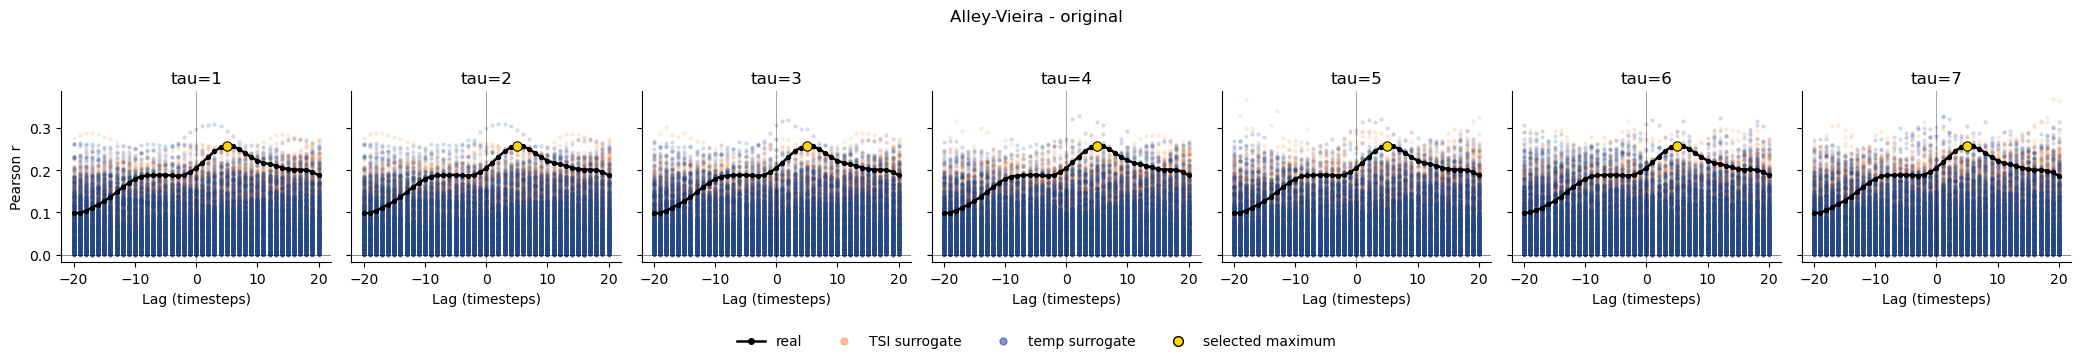

In [55]:
diagnostic_specs_df, _ = build_run_specs(run_pair_labels=[single_pair_label], run_row_categories=[single_row_category])
if len(diagnostic_specs_df) != 1:
    raise ValueError('The diagnostic selection must identify exactly one dyad and treatment.')
spec = diagnostic_specs_df.iloc[0]
x_id, y_id = spec['var_x_id'], spec['var_y_id']
(real_df, surr_df, summary_df), _ = compute_corr_tau_tables_cached(
    x_id, y_id, tau_values=single_run_tau_values, lag_ts_limit=lag_ts_limit, min_lag=min_lag,
)
if summary_df is None:
    raise RuntimeError('The selected diagnostic dyad did not produce a correlation summary.')
x_obj, y_obj = load_master_var_object(x_id), load_master_var_object(y_id)
palette = {
    f'{x_id}_real__{y_id}_surr': getattr(y_obj, 'color', 'tab:orange'),
    f'{x_id}_surr__{y_id}_real': getattr(x_obj, 'color', 'tab:blue'),
}
labels = {
    f'{x_id}_real__{y_id}_surr': f'{getattr(y_obj, "var", y_id)} surrogate',
    f'{x_id}_surr__{y_id}_real': f'{getattr(x_obj, "var", x_id)} surrogate',
}
taus = sorted(summary_df['tau'].unique())
fig, axes = plt.subplots(1, len(taus), figsize=(3.0 * len(taus), 3.35), sharey=True, squeeze=False)
for ax, tau in zip(axes.ravel(), taus):
    real = real_df.loc[real_df['tau'] == tau].sort_values('lag')
    surr = surr_df.loc[surr_df['tau'] == tau]
    selected = summary_df.loc[summary_df['tau'] == tau].iloc[0]
    ax.plot(real['lag'], real['rho'], color='black', lw=1.8, marker='o', markersize=2.8, zorder=3)
    for relation, rel_df in surr.groupby('relation'):
        ax.scatter(rel_df['lag'], rel_df['rho'], s=9, alpha=0.20, color=palette.get(relation, '0.5'), linewidths=0, zorder=1)
    ax.scatter([selected['lag']], [selected['rho']], s=45, color='gold', edgecolors='black', linewidths=0.75, zorder=4)
    ax.axhline(0, color='black', lw=0.7, alpha=0.45)
    ax.axvline(0, color='black', lw=0.7, alpha=0.35)
    ax.set_title(f'tau={tau}')
    ax.set_xlabel('Lag (timesteps)')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
axes[0, 0].set_ylabel('Pearson r')
handles = [Line2D([], [], color='black', marker='o', markersize=4, lw=1.8, label='real')]
handles += [Line2D([], [], color=color, marker='o', markersize=5, lw=0, alpha=0.55, label=labels[relation]) for relation, color in palette.items()]
handles += [Line2D([], [], color='gold', marker='o', markeredgecolor='black', markersize=7, lw=0, label='selected maximum')]
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(f'{single_pair_label} - {single_row_category}', y=1.01)
fig.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()


## Complete canonical batch

Once the single-dyad diagnostic looks right, execute the next cell to calculate all
canonical dyads, all three treatments, and all tau values. It returns the compact
assignment table needed downstream; it does not save the large lag-profile tables.


In [56]:
# Execute this cell when you are ready for the complete correlation calculation.
# batch_assignment_corr_df = run_corr_experiment(
#     pair_labels=None,
#     row_categories=ROW_CATEGORIES,
#     tau_values=tau_values,
# )


## Update the compact plot input

The table below is the only persisted output. It contains the selected maximum and surrogate fractions needed by the ResultsGrid plot; the heavier lag-profile tables remain in this session-only cache for the diagnostic above.


In [57]:
# if run_assignment_corr_df is None or run_assignment_corr_df.empty:
#     raise RuntimeError('Nothing to persist. Run the selected experiment first.')
#
# assignment_path.parent.mkdir(parents=True, exist_ok=True)
# assignment_columns = run_assignment_corr_df.columns.tolist()
# key_cols = [
#     'pair_label', 'row_category', 'relationship_id', 'E', 'tau',
#     'role', 'criterium_label',
# ]
# incoming = run_assignment_corr_df.copy()
# if assignment_path.exists():
#     existing = pd.read_csv(assignment_path).reindex(columns=assignment_columns)
#     existing_key = existing[key_cols].fillna('').astype(str).agg('|'.join, axis=1)
#     incoming_key = incoming[key_cols].fillna('').astype(str).agg('|'.join, axis=1)
#     existing = existing.loc[~existing_key.isin(set(incoming_key))]
#     combined = pd.concat([existing, incoming], ignore_index=True)
# else:
#     combined = incoming
# combined = combined.sort_values(['pair_label', 'row_category', 'E', 'tau']).reset_index(drop=True)
# # combined.to_csv(assignment_path, index=False)
# print(f'Wrote {len(combined)} rows: {assignment_path}')
